In [15]:
import pandas as pd
import numpy as np
import joblib

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

from xgboost import XGBClassifier

import matplotlib.pyplot as plt
import seaborn as sns

In [16]:
# ============================================================
# LOAD DATASET
# ============================================================

df = pd.read_csv(r"D:\Power_System_Fault Detection\dataset\fault_data.csv")

print("Dataset Shape:", df.shape)
print(df.head())

Dataset Shape: (506, 13)
  Fault ID           Fault Type Fault Location (Latitude, Longitude)  \
0     F001        Line Breakage                 (34.0522, -118.2437)   
1     F002  Transformer Failure                   (34.056, -118.245)   
2     F003          Overheating                  (34.0525, -118.244)   
3     F004        Line Breakage                   (34.055, -118.242)   
4     F005  Transformer Failure                  (34.0545, -118.243)   

   Voltage (V)  Current (A)  Power Load (MW)  Temperature (°C)  \
0         2200          250               50                25   
1         1800          180               45                28   
2         2100          230               55                35   
3         2050          240               48                23   
4         1900          190               50                30   

   Wind Speed (km/h) Weather Condition Maintenance Status Component Health  \
0                 20             Clear          Scheduled          

In [17]:
# ============================================================
# REMOVE IRRELEVANT COLUMNS
# ============================================================

if "Fault ID" in df.columns:
    df.drop(columns=["Fault ID"], inplace=True)

In [18]:
# ============================================================
# TARGET VARIABLE
# ============================================================

TARGET_COLUMN = "Fault Type"

X = df.drop(columns=[TARGET_COLUMN])
y = df[TARGET_COLUMN]

In [19]:
# ============================================================
# LABEL ENCODE TARGET
# ============================================================

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

In [20]:
# ============================================================
# FEATURE ENGINEERING
# ============================================================

# Voltage/Current ratio
if ("Voltage" in X.columns) and ("Current" in X.columns):
    X["V_I_Ratio"] = X["Voltage"] / (X["Current"] + 1e-6)

# Power efficiency
if (
    "Power Load" in X.columns
    and "Voltage" in X.columns
    and "Current" in X.columns
):
    X["Power_Factor_Approx"] = (
        X["Power Load"] /
        ((X["Voltage"] * X["Current"]) + 1e-6)
    )
# Fault duration impact
if (
    "Duration of Fault" in X.columns
    and "Down time" in X.columns
):
    X["Downtime_Ratio"] = (
        X["Down time"] /
        (X["Duration of Fault"] + 1e-6)
    )


In [21]:
# ============================================================
# IDENTIFY COLUMN TYPES
# ============================================================

numeric_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()

print("\nNumeric Features:")
print(numeric_features)

print("\nCategorical Features:")
print(categorical_features)


Numeric Features:
['Voltage (V)', 'Current (A)', 'Power Load (MW)', 'Temperature (°C)', 'Wind Speed (km/h)', 'Duration of Fault (hrs)', 'Down time (hrs)']

Categorical Features:
['Fault Location (Latitude, Longitude)', 'Weather Condition', 'Maintenance Status', 'Component Health']


C:\Users\Srikanth Pydikalva\AppData\Local\Temp\ipykernel_24276\4228284248.py:9: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(


In [22]:
# ============================================================
# PREPROCESSING
# ============================================================

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [23]:
# ============================================================
# MODEL
# ============================================================

model = XGBClassifier(
    objective="multi:softprob",
    num_class=len(np.unique(y_encoded)),
    n_estimators=300,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="mlogloss",
    random_state=42
)


In [24]:
# ============================================================
# PIPELINE
# ============================================================

pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", model)
    ]
)

# ============================================================
# TRAIN TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)


In [25]:
# ============================================================
# TRAIN
# ============================================================

print("\nTraining model...")

pipeline.fit(X_train, y_train)

print("Training completed!")

# ============================================================
# PREDICTIONS
# ============================================================

y_pred = pipeline.predict(X_test)



Training model...
Training completed!


In [26]:
# EVALUATION
# ============================================================

accuracy = accuracy_score(y_test, y_pred)

print("\nAccuracy:", round(accuracy * 100, 2), "%")

print("\nClassification Report:\n")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=label_encoder.classes_
    )
)



Accuracy: 36.27 %

Classification Report:

                     precision    recall  f1-score   support

      Line Breakage       0.30      0.24      0.27        33
        Overheating       0.38      0.40      0.39        35
Transformer Failure       0.39      0.44      0.42        34

           accuracy                           0.36       102
          macro avg       0.36      0.36      0.36       102
       weighted avg       0.36      0.36      0.36       102



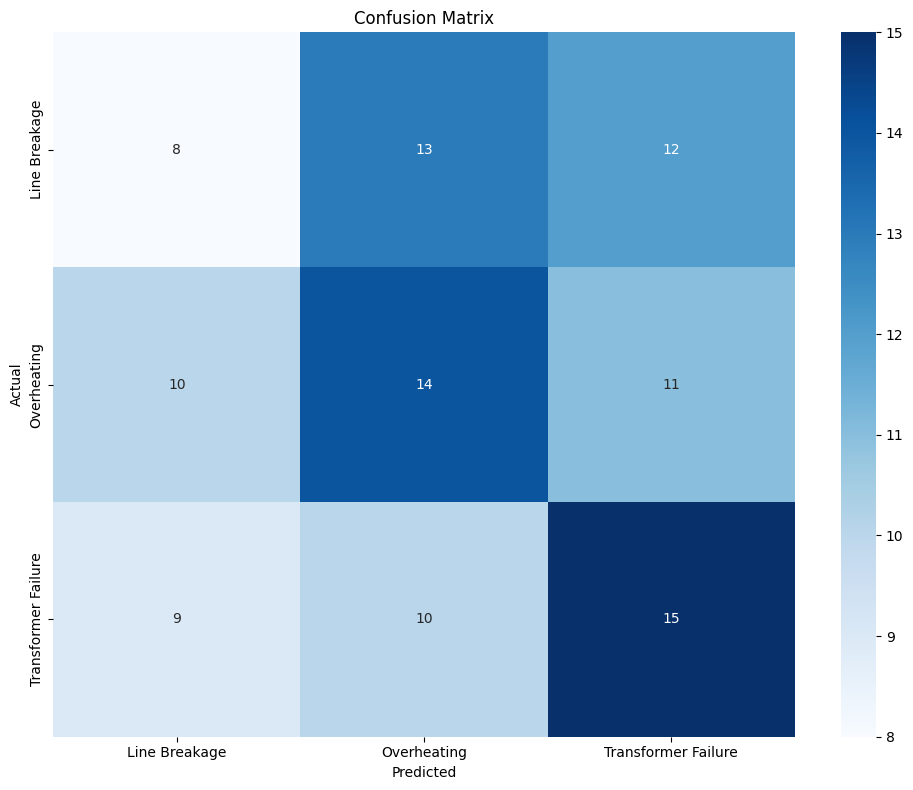

In [27]:
# ============================================================
# CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()



Top 20 Important Features:

                                               Feature  Importance
413                       cat__Weather Condition_Snowy    0.062232
414                cat__Weather Condition_Thunderstorm    0.060358
420                       cat__Component Health_Normal    0.059816
5                         num__Duration of Fault (hrs)    0.058164
412                       cat__Weather Condition_Rainy    0.058026
1                                     num__Current (A)    0.057170
421                   cat__Component Health_Overheated    0.057060
6                                 num__Down time (hrs)    0.056699
415                   cat__Weather Condition_Windstorm    0.056431
0                                     num__Voltage (V)    0.056089
417                    cat__Maintenance Status_Pending    0.055516
4                               num__Wind Speed (km/h)    0.054155
2                                 num__Power Load (MW)    0.053693
3                                

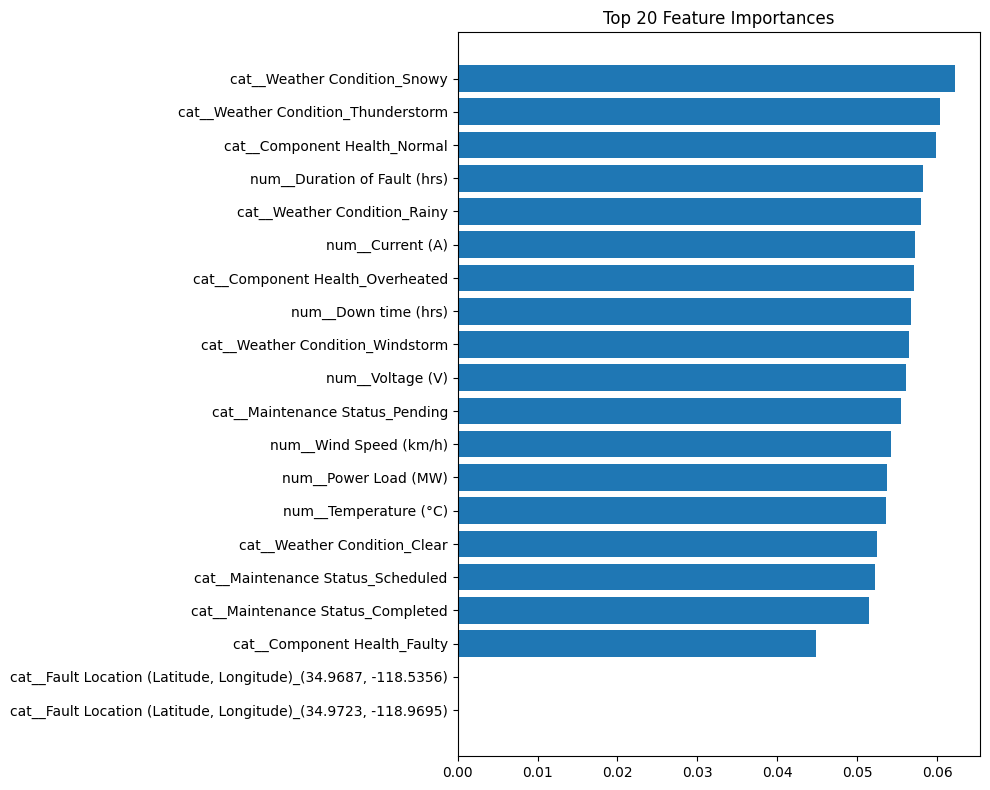

In [28]:
# FEATURE IMPORTANCE
# ============================================================

xgb_model = pipeline.named_steps["classifier"]

importances = xgb_model.feature_importances_

feature_names = (
    pipeline.named_steps["preprocessor"]
    .get_feature_names_out()
)

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)
print("\nTop 20 Important Features:\n")
print(importance_df.head(20))

plt.figure(figsize=(10, 8))

top_features = importance_df.head(20)

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.gca().invert_yaxis()

plt.title("Top 20 Feature Importances")
plt.tight_layout()
plt.show()

In [29]:
joblib.dump(
    pipeline,
    "fault_detection_model.pkl"
)

joblib.dump(
    label_encoder,
    "fault_label_encoder.pkl"
)

print("\nModel saved successfully!")


Model saved successfully!


In [32]:
import pandas as pd
import joblib

model = joblib.load("fault_detection_model.pkl")
label_encoder = joblib.load("fault_label_encoder.pkl")

new_sample = pd.DataFrame({
    "Voltage (V)": [228],
    "Current (A)": [18],
    "Power Load (MW)": [4100],
    "Temperature (°C)": [42],
    "Wind Speed (km/h)": [10],
    "Weather Condition": ["Rainy"],
    "Maintenance Status": ["Pending"],
    "Component Health": ["Poor"],
    "Fault Location (Latitude, Longitude)": [(17.3850, 78.4867)],
    "Duration of Fault (hrs)": [45],
    "Down time (hrs)": [30]
})

prediction = model.predict(new_sample)

fault_type = label_encoder.inverse_transform(prediction)

print("Predicted Fault:", fault_type[0])

Predicted Fault: Transformer Failure
